<a href="https://colab.research.google.com/github/SitiMutmainah15/PCVK_GENAP_2026/blob/main/Modul6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [14]:
def convolution2d(image, kernel, stride, padding):
    # Menambahkan padding pada citra
    image_padded = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )

    # Menentukan ukuran citra dan kernel
    image_height, image_width = image_padded.shape
    kernel_height, kernel_width = kernel.shape

    # Menentukan ukuran output
    output_height = (image_height - kernel_height) // stride + 1
    output_width = (image_width - kernel_width) // stride + 1

    # Membuat matriks output
    output = np.zeros((output_height, output_width))

    # Melakukan perhitungan filter secara manual
    for y in range(output_height):
        for x in range(output_width):
            region = image_padded[
                y * stride:y * stride + kernel_height,
                x * stride:x * stride + kernel_width
            ]

            output[y, x] = np.sum(region * kernel)

    return output

In [15]:
# Load image yang akan diproses
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')

# Mengubah gambar menjadi grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [16]:
# Image Sharpen
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

In [17]:
convolution2d(img_gray, kernel_sharpen, 1, 2)

array([[   0., -145.,  -56., ..., -153., -177.,    0.],
       [-145.,  553.,  -15., ...,  326.,  607., -177.],
       [-116.,  257.,  179., ...,  249.,  218., -125.],
       ...,
       [-156.,  487.,  262., ...,  159.,  183.,  -69.],
       [ -11., -112., -110., ...,  -71.,  -53.,   -4.],
       [   0.,  -11.,  -11., ...,   -4.,   -4.,    0.]])

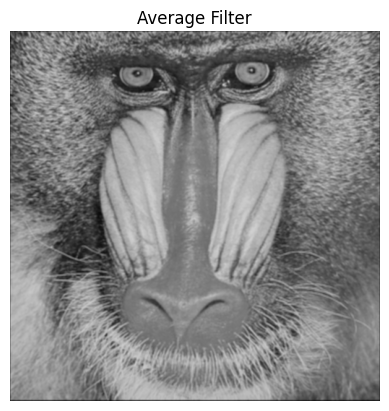

In [18]:
# Average Filter 3x3
kernel_average = np.ones((3, 3), dtype=np.float32) / 9

hasil_average = convolution2d(img_gray, kernel_average, 1, 1)
hasil_average = np.clip(hasil_average, 0, 255).astype(np.uint8)

plt.imshow(hasil_average, cmap='gray', vmin=0, vmax=255)
plt.title('Average Filter')
plt.axis('off')
plt.show()

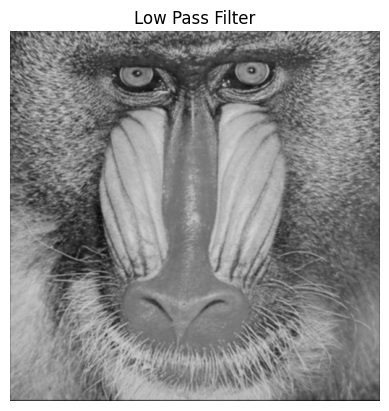

In [19]:
# Low Pass Filter
kernel_lowpass = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
], dtype=np.float32) / 12

hasil_lowpass = convolution2d(img_gray, kernel_lowpass, 1, 1)
hasil_lowpass = np.clip(hasil_lowpass, 0, 255).astype(np.uint8)

plt.imshow(hasil_lowpass, cmap='gray', vmin=0, vmax=255)
plt.title('Low Pass Filter')
plt.axis('off')
plt.show()

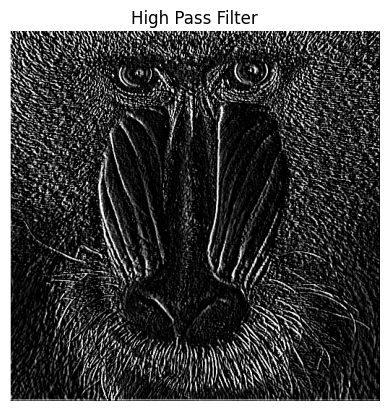

In [20]:
# High Pass Filter
kernel_highpass = np.array([
    [-1, 0, 1],
    [-1, 0, 3],
    [-3, 0, 1]
])

hasil_highpass = convolution2d(img_gray, kernel_highpass, 1, 1)
hasil_highpass = np.clip(hasil_highpass, 0, 255).astype(np.uint8)

plt.imshow(hasil_highpass, cmap='gray', vmin=0, vmax=255)
plt.title('High Pass Filter')
plt.axis('off')
plt.show()

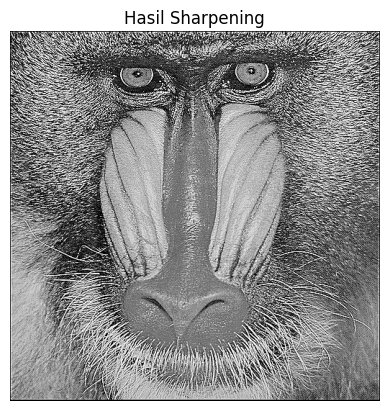

In [21]:
# Menjalankan konvolusi sharpening
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

# Membatasi nilai piksel
hasil_sharpen = np.clip(hasil_sharpen, 0, 255).astype(np.uint8)

# Menampilkan hasil sharpening
plt.imshow(hasil_sharpen, cmap='gray')
plt.title('Hasil Sharpening')
plt.axis('off')
plt.show()

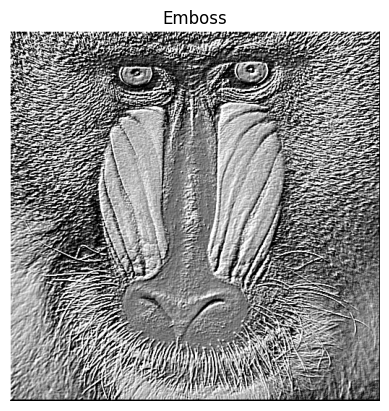

In [22]:
# Emboss Filter
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
])

hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 1)
hasil_emboss = np.clip(hasil_emboss, 0, 255).astype(np.uint8)

plt.imshow(hasil_emboss, cmap='gray', vmin=0, vmax=255)
plt.title('Emboss')
plt.axis('off')
plt.show()

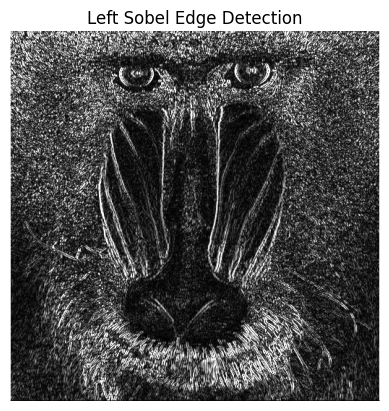

In [23]:
# Left Sobel Edge Detection
kernel_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

hasil_sobel = convolution2d(img_gray, kernel_sobel, 1, 1)
hasil_sobel = np.clip(np.abs(hasil_sobel), 0, 255).astype(np.uint8)

plt.imshow(hasil_sobel, cmap='gray', vmin=0, vmax=255)
plt.title('Left Sobel Edge Detection')
plt.axis('off')
plt.show()

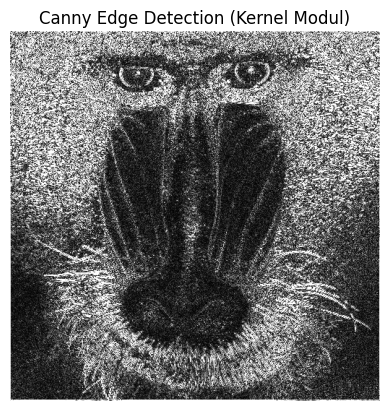

In [24]:
# Edge Detection - Kernel pada modul
kernel_canny = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

hasil_canny = convolution2d(img_gray, kernel_canny, 1, 1)
hasil_canny = np.clip(np.abs(hasil_canny), 0, 255).astype(np.uint8)

plt.imshow(hasil_canny, cmap='gray', vmin=0, vmax=255)
plt.title('Canny Edge Detection (Kernel Modul)')
plt.axis('off')
plt.show()

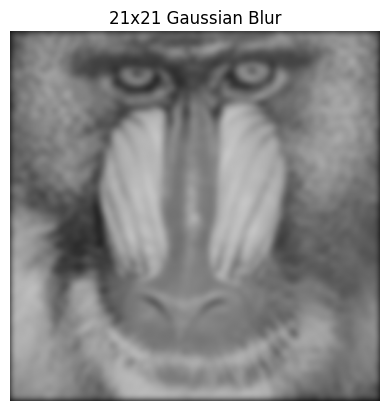

In [25]:
# Gaussian Blur 21x21
kernel_size = 21

sigma = math.sqrt(kernel_size)

gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)

gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

hasil_gaussian = convolution2d(img_gray, gauss_kernel, 1, 10)
hasil_gaussian = np.clip(hasil_gaussian, 0, 255).astype(np.uint8)

plt.imshow(hasil_gaussian, cmap='gray', vmin=0, vmax=255)
plt.title('21x21 Gaussian Blur')
plt.axis('off')
plt.show()

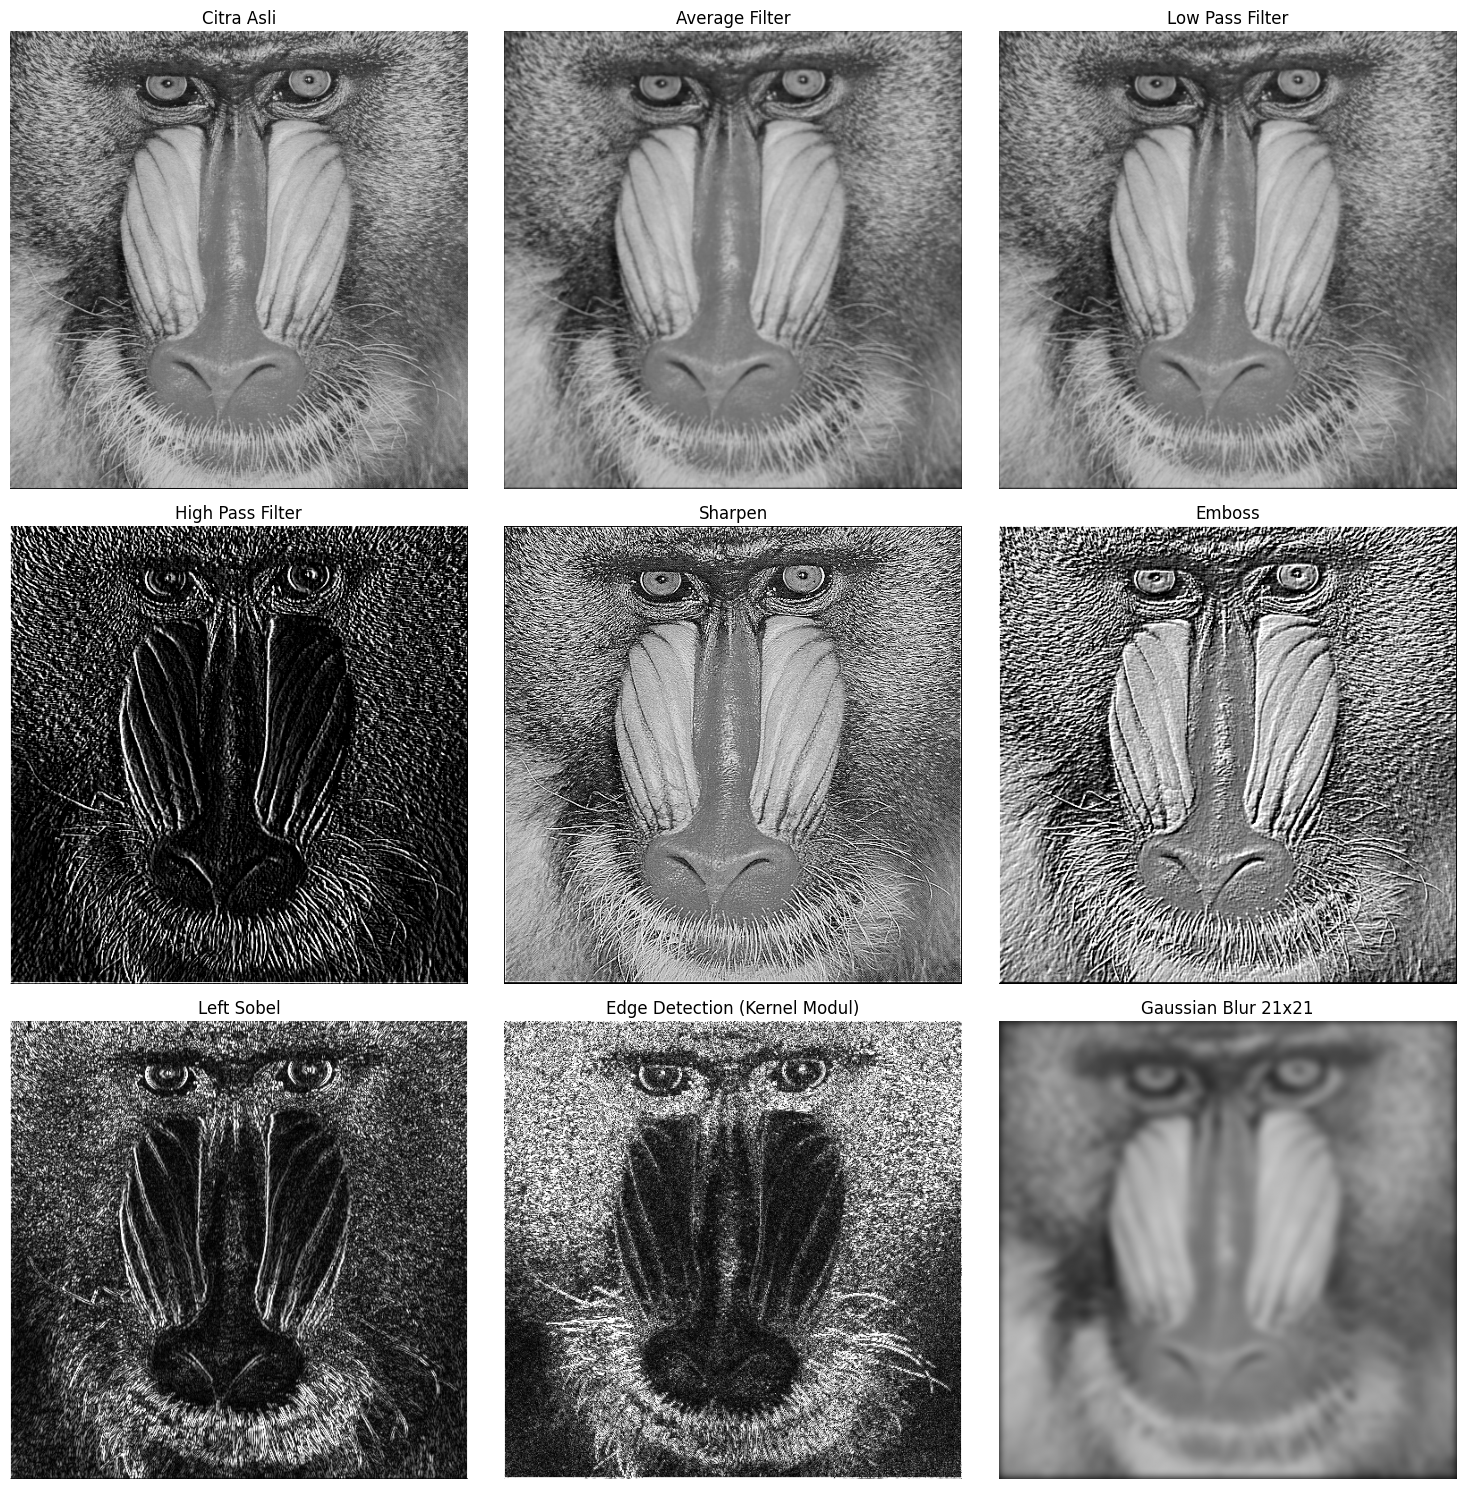

In [26]:
# Perbandingan seluruh hasil filter
gambar = [
    img_gray,
    hasil_average,
    hasil_lowpass,
    hasil_highpass,
    hasil_sharpen,
    hasil_emboss,
    hasil_sobel,
    hasil_canny,
    hasil_gaussian
]

judul = [
    'Citra Asli',
    'Average Filter',
    'Low Pass Filter',
    'High Pass Filter',
    'Sharpen',
    'Emboss',
    'Left Sobel',
    'Edge Detection (Kernel Modul)',
    'Gaussian Blur 21x21'
]

plt.figure(figsize=(15, 15))

for i in range(len(gambar)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(gambar[i], cmap='gray', vmin=0, vmax=255)
    plt.title(judul[i])
    plt.axis('off')

plt.tight_layout()
plt.show()